In [6]:
import pandas as pd
import numpy as np
import pyro
import torch

np.random.seed(13625442)

# 1: Load the Dataset

In [7]:
ratings_df = pd.read_csv("Dataset/jester_ratings.csv")  
jokes_df = pd.read_csv("Dataset/jester_items.csv")

print(f"Ratings: {ratings_df.shape}\nJokes: {jokes_df.shape}")
print(ratings_df.head())
print(jokes_df.head())

Ratings: (1761439, 3)
Jokes: (150, 2)
   userId  jokeId  rating
0       1       5   0.219
1       1       7  -9.281
2       1       8  -9.281
3       1      13  -6.781
4       1      15   0.875
   jokeId                                           jokeText
0       1  A man visits the doctor. The doctor says "I ha...
1       2  This couple had an excellent relationship goin...
2       3  Q. What's 200 feet long and has 4 teeth? \n\nA...
3       4  Q. What's the difference between a man and a t...
4       5  Q.\tWhat's O. J. Simpson's Internet address? \...


# 2: Filter the Dataset to be smaller 

In [8]:
JOKE_COUNT = 50
USER_COUNT = 1000

#order jokes by the jokes that are rated the most often and take the top JOKE_COUNT jokes
top_jokeIds = ratings_df['jokeId'].value_counts().head(JOKE_COUNT).index.tolist()

#copy the dataset with only the jokes from last step
filtered_df = ratings_df[ratings_df['jokeId'].isin(top_jokeIds)].copy()

#order the users by how many of the jokes they rated in our filtered_df, 
#then keep the users that rated more than 4/5ths of the jokes
user_counts = filtered_df['userId'].value_counts()
active_users = user_counts[user_counts >= (JOKE_COUNT//5)*4].index
filtered_df = filtered_df[filtered_df['userId'].isin(active_users)]

#rearrange the df such that every row is a single user and every column is a joke
pivot_df = filtered_df.pivot(index='userId', columns='jokeId', values='rating')[:USER_COUNT]

#mask out NANs 
mask_np = pivot_df.notna().astype(float).values
mask_tensor = torch.tensor(mask_np, dtype=torch.float32)

def binarize_rating(val):
    """Convert positive values to 1.0 and negative values to 0.0."""
    return 1.0 if val > 0.0 else 0.0

#create tensor for model
binary_ratings_np = pivot_df.map(binarize_rating).values
ratings_tensor = torch.tensor(binary_ratings_np, dtype=torch.float32)

#reconstruct jokeText for pretty printing later
ordered_jokeIds = pivot_df.columns.tolist()
top_jokes_text = [
    jokes_df[jokes_df['jokeId'] == j_id]['jokeText'].values[0] 
    for j_id in ordered_jokeIds
]

print(f"Data ready! Matrix shape: {ratings_tensor.shape} (Users x Jokes)")

Data ready! Matrix shape: torch.Size([1000, 50]) (Users x Jokes)


# 2.5 Print the Funniest Joke (for fun)

In [9]:

joke_scores = binary_ratings_np.sum(axis=0)
sorted_joke_indices = np.argsort(joke_scores)

funniest_joke_idx = sorted_joke_indices[-1]
highest_score = joke_scores[funniest_joke_idx]

print(f"Funniest Joke:\n{top_jokes_text[funniest_joke_idx]}")

Funniest Joke:
A radio conversation of a US naval 
ship with Canadian authorities ... 

Americans: Please divert your course 15 degrees to the North to avoid a
collision.

Canadians: Recommend you divert YOUR course 15 degrees to the South to 
avoid a collision.

Americans: This is the Captain of a US Navy ship.  I say again, divert 
YOUR course.

Canadians: No.  I say again, you divert YOUR course.

Americans: This is the aircraft carrier USS LINCOLN, the second largest ship in the United States' Atlantic Fleet. We are accompanied by three destroyers, three cruisers and numerous support vessels. I demand that you change your course 15 degrees north, that's ONE FIVE DEGREES NORTH, or counter-measures will be undertaken to ensure the safety of this ship.

Canadians: This is a lighthouse.  Your call.



# 3: Define the model

In [10]:
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoNormal
from pyro.optim import Adam
import torch

def ising_jester_model(user_ratings, mask):
    n_users, n_jokes = user_ratings.shape
    
    #instantiate model parameters
    h_prior = dist.Normal(torch.zeros(n_jokes), torch.ones(n_jokes))
    J_prior = dist.Normal(torch.zeros(n_jokes, n_jokes), torch.ones(n_jokes, n_jokes) * 0.1)
    
    h = pyro.sample("h", h_prior.to_event(1))
    J_raw = pyro.sample("J_raw", J_prior.to_event(2))
    
    #create symmetrical matrix and eliminate diagonal entries
    J_sym = (J_raw + J_raw.T) / 2.0
    J = J_sym - torch.diag(torch.diag(J_sym)) 
    
    with pyro.plate("users", n_users):
        observed_states = user_ratings * mask
        
        #convert {0,1} -> {-1,1}
        spins = (2.0 * observed_states - 1.0) * mask
        
        #effective field for ising learning
        effective_field = 2.0 * h + 2.0 * torch.matmul(spins, J)
        prob_funny = torch.special.expit(effective_field)

        masked_dist = dist.Bernoulli(probs=prob_funny).mask(mask.bool()).to_event(1)
        pyro.sample("obs_ratings", masked_dist, obs=user_ratings)



In [11]:
total_users, total_jokes = ratings_tensor.shape
base_train_mask = mask_tensor.clone()
test_targets = []
STEPS = 1000

#create a test set of 1 joke per user
for u in range(total_users):
    rated_indices = torch.where(mask_tensor[u] == 1.0)[0]
    target_joke = rated_indices[np.random.randint(0, len(rated_indices))].item()
    base_train_mask[u, target_joke] = 0.0
    test_targets.append((u, target_joke, ratings_tensor[u, target_joke].item()))

keep_rates = [0.10, 0.25, 0.5, 0.75, 1.0]
results_log = []


for keep_rate in keep_rates:
    #generate a mask, keeping only keep_rate% of entries
    random_dropout = (torch.rand(total_users, total_jokes) < keep_rate).float()
    sparse_train_mask = base_train_mask * random_dropout
    
    #get a count of the ratings
    ratings_count = int(sparse_train_mask.sum().item())
    
    #reset the model
    pyro.clear_param_store()
    guide = AutoNormal(ising_jester_model)
    optimizer = Adam({"lr": 0.01})
    svi = SVI(ising_jester_model, guide, optimizer, loss=Trace_ELBO())
    
    #train
    for step in range(STEPS):  
        loss = svi.step(ratings_tensor, sparse_train_mask)
        
    #extract the parameters
    post_means = guide.median()
    learned_h = post_means["h"]
    learned_J_raw = post_means["J_raw"]
    learned_J = (learned_J_raw + learned_J_raw.T) / 2.0 - torch.diag(torch.diag((learned_J_raw + learned_J_raw.T) / 2.0))
    
    #evaluate
    obs_states = ratings_tensor * sparse_train_mask
    spins = (2.0 * obs_states - 1.0) * sparse_train_mask
    eff_field = 2.0 * learned_h + 2.0 * torch.matmul(spins, learned_J)
    probs = torch.special.expit(eff_field)
    
    #accuracy
    correct, total = 0, 0
    for u, j, actual in test_targets:
        pred = 1.0 if probs[u, j].item() >= 0.5 else 0.0
        if pred == actual:
            correct += 1
        total += 1
            
    accuracy = (correct / total * 100) if total > 0 else 0
    results_log.append({"Keep Rate": keep_rate, "Active Ratings": ratings_count, "Accuracy": accuracy})
    
    print(f"Kept {keep_rate*100}% Data | Ratings Used: {ratings_count:>5} | Test Accuracy: {accuracy:.2f}%")


Kept 10.0% Data | Ratings Used:  4576 | Test Accuracy: 76.20%
Kept 25.0% Data | Ratings Used: 11585 | Test Accuracy: 78.60%
Kept 50.0% Data | Ratings Used: 23049 | Test Accuracy: 79.10%
Kept 75.0% Data | Ratings Used: 34695 | Test Accuracy: 80.50%
Kept 100.0% Data | Ratings Used: 46185 | Test Accuracy: 81.20%


In [12]:
funniest_joke_idx = torch.argmax(learned_h).item()
funniest_joke_bias = learned_h[funniest_joke_idx].item()

print(f"Funniest Joke(model edition)\n{top_jokes_text[funniest_joke_idx]}")
print(f"Intrinsic Bias (h): {funniest_joke_bias:.4f}")



Funniest Joke(model edition)
A radio conversation of a US naval 
ship with Canadian authorities ... 

Americans: Please divert your course 15 degrees to the North to avoid a
collision.

Canadians: Recommend you divert YOUR course 15 degrees to the South to 
avoid a collision.

Americans: This is the Captain of a US Navy ship.  I say again, divert 
YOUR course.

Canadians: No.  I say again, you divert YOUR course.

Americans: This is the aircraft carrier USS LINCOLN, the second largest ship in the United States' Atlantic Fleet. We are accompanied by three destroyers, three cruisers and numerous support vessels. I demand that you change your course 15 degrees north, that's ONE FIVE DEGREES NORTH, or counter-measures will be undertaken to ensure the safety of this ship.

Canadians: This is a lighthouse.  Your call.

Intrinsic Bias (h): 0.4097


# 4: Calibration Curve

A calibration curve checks whether the model's predicted probabilities are trustworthy.
We bin all test predictions by their confidence (e.g. 0-10%, 10-20%, ...) and plot
predicted probability vs. actual fraction correct in that bin.
A perfectly calibrated model falls on the diagonal.

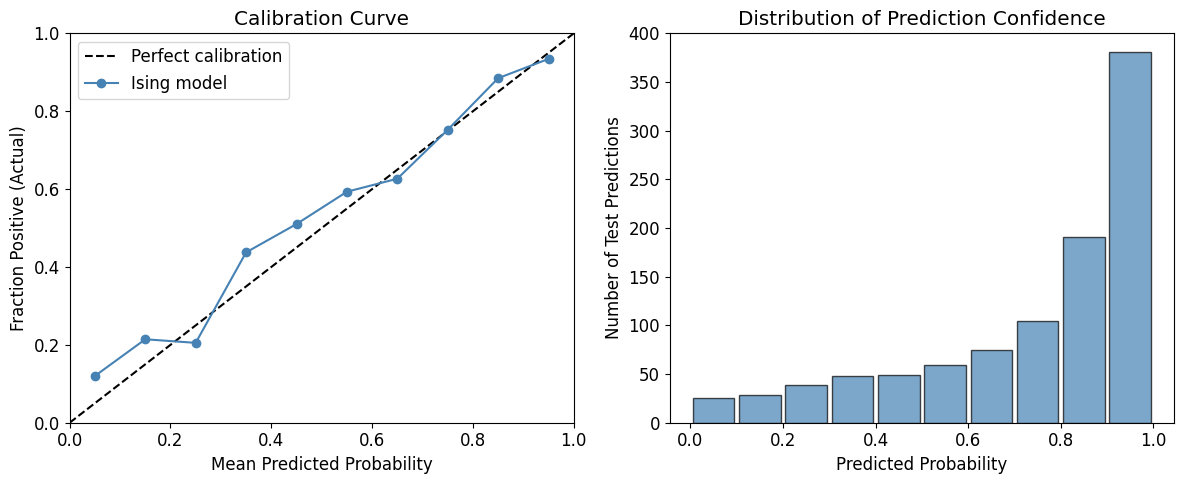

Calibration curve saved to calibration_curve.png


In [14]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 12})

# Use the fully-trained model (keep_rate=1.0, last iteration of the loop above)
# Re-compute predicted probabilities on the test set using full training mask (no extra dropout)
obs_states_full = ratings_tensor * base_train_mask
spins_full = (2.0 * obs_states_full - 1.0) * base_train_mask
eff_field_full = 2.0 * learned_h + 2.0 * torch.matmul(spins_full, learned_J)
probs_full = torch.special.expit(eff_field_full)

# Gather predicted probability and ground truth for each test target
pred_probs = np.array([probs_full[u, j].item() for u, j, _ in test_targets])
actuals    = np.array([actual              for _, _, actual in test_targets])

# Bin predictions into 10 equal-width buckets
N_BINS = 10
bins = np.linspace(0, 1, N_BINS + 1)
bin_centers, bin_acc, bin_counts = [], [], []

for i in range(N_BINS):
    lo, hi = bins[i], bins[i + 1]
    mask_bin = (pred_probs >= lo) & (pred_probs < hi)
    if mask_bin.sum() == 0:
        continue
    bin_centers.append((lo + hi) / 2)
    bin_acc.append(actuals[mask_bin].mean())
    bin_counts.append(mask_bin.sum())

bin_centers = np.array(bin_centers)
bin_acc     = np.array(bin_acc)
bin_counts  = np.array(bin_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: calibration curve
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.plot(bin_centers, bin_acc, 'o-', color='steelblue', label='Ising model')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction Positive (Actual)')
ax.set_title('Calibration Curve')
ax.legend()
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# Right: histogram of prediction confidence
ax2 = axes[1]
ax2.bar(bin_centers, bin_counts, width=0.09, color='steelblue', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Predicted Probability')
ax2.set_ylabel('Number of Test Predictions')
ax2.set_title('Distribution of Prediction Confidence')

plt.tight_layout()
plt.savefig('calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Calibration curve saved to calibration_curve.png')

# 5: Joke Clustering via Learned J Matrix

The coupling matrix J encodes how jokes relate to each other — positive J[i,j] means
users tend to rate jokes i and j similarly; negative means they tend to disagree.
We use hierarchical clustering on J to find groups of jokes with similar taste profiles,
and plot a heatmap so the structure is visually clear.

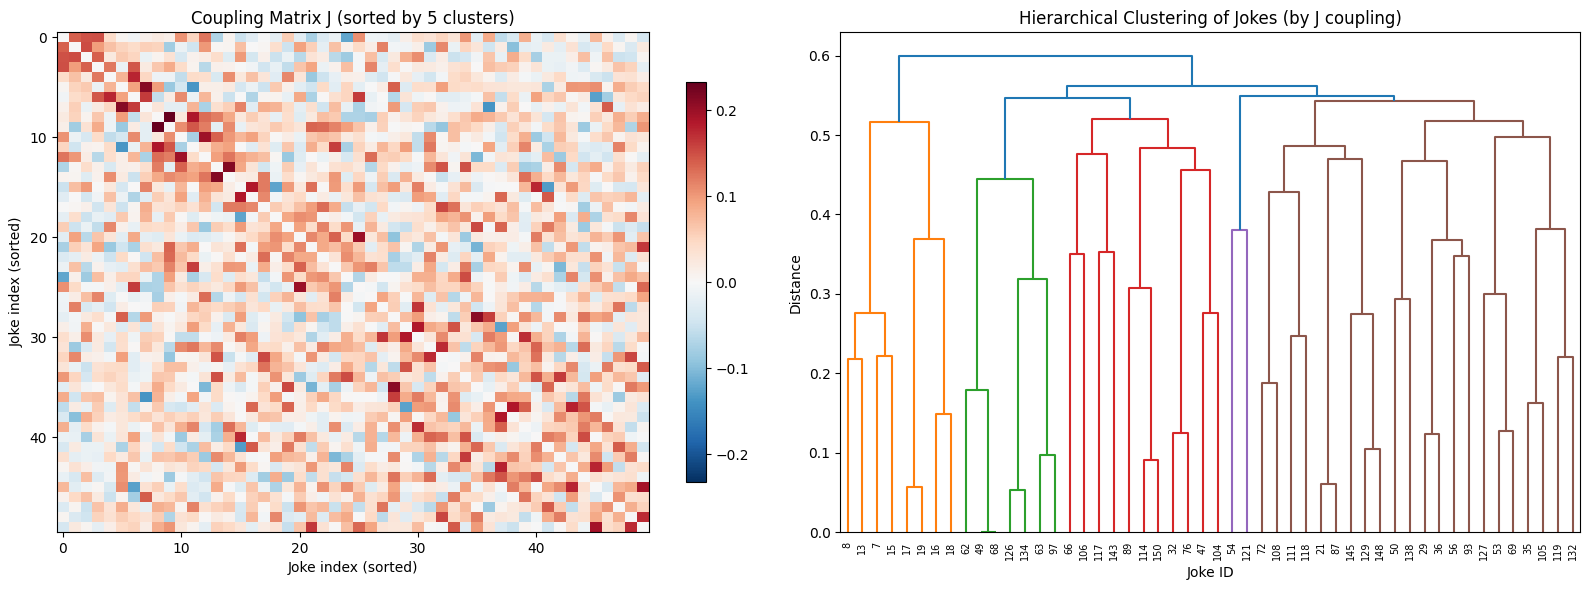

Cluster assignments (N=5):

  Cluster 1 (8 jokes, mean bias h=-0.201): joke IDs [7, 8, 13, 15, 16, 17, 18, 19]
  Cluster 2 (7 jokes, mean bias h=0.005): joke IDs [49, 62, 63, 68, 97, 126, 134]
  Cluster 3 (11 jokes, mean bias h=0.082): joke IDs [32, 47, 66, 76, 89, 104, 106, 114, 117, 143, 150]
  Cluster 4 (2 jokes, mean bias h=-0.072): joke IDs [54, 121]
  Cluster 5 (22 jokes, mean bias h=0.069): joke IDs [21, 29, 35, 36, 50, 53, 56, 69, 72, 87, 93, 105, 108, 111, 118, 119, 127, 129, 132, 138, 145, 148]


In [16]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 10})

J_np = learned_J.detach().numpy()
h_np = learned_h.detach().numpy()

# Convert J into a distance matrix: high positive coupling -> similar -> small distance
J_sim = (J_np - J_np.min()) / (J_np.max() - J_np.min())  # scale to [0,1]
dist_matrix = 1.0 - J_sim
np.fill_diagonal(dist_matrix, 0.0)
dist_matrix = (dist_matrix + dist_matrix.T) / 2.0  # ensure symmetry

# Hierarchical clustering
condensed = squareform(dist_matrix)
Z = linkage(condensed, method='average')

N_CLUSTERS = 5
cluster_labels = fcluster(Z, N_CLUSTERS, criterion='maxclust')

# Sort jokes by cluster for a clean heatmap
sort_order = np.argsort(cluster_labels)
J_sorted = J_np[np.ix_(sort_order, sort_order)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: heatmap of sorted J
ax = axes[0]
vmax = np.abs(J_np).max()
im = ax.imshow(J_sorted, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title(f'Coupling Matrix J (sorted by {N_CLUSTERS} clusters)')
ax.set_xlabel('Joke index (sorted)'); ax.set_ylabel('Joke index (sorted)')

# Right: dendrogram
ax2 = axes[1]
dendrogram(Z, ax=ax2, color_threshold=Z[-(N_CLUSTERS-1), 2],
           labels=[str(jid) for jid in ordered_jokeIds],
           leaf_rotation=90, leaf_font_size=7)
ax2.set_title('Hierarchical Clustering of Jokes (by J coupling)')
ax2.set_xlabel('Joke ID'); ax2.set_ylabel('Distance')

plt.tight_layout()
plt.savefig('joke_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

# Print cluster summary
print(f'Cluster assignments (N={N_CLUSTERS}):\n')
for c in range(1, N_CLUSTERS + 1):
    idxs = np.where(cluster_labels == c)[0]
    joke_ids_in_cluster = [ordered_jokeIds[i] for i in idxs]
    mean_h = h_np[idxs].mean()
    print(f'  Cluster {c} ({len(idxs)} jokes, mean bias h={mean_h:.3f}): joke IDs {joke_ids_in_cluster}')